In [1]:
import pandas as pd

df = pd.read_csv("data/processed_data/trades_daily_with_sentiment.csv")

df.head()
df.describe(include='all')


,account,date,daily_pnl,num_trades,volume_usd,avg_trade_size_usd,long_fraction,total_fee_usd,crossed_fraction,avg_start_position,...,pnl_per_usd_traded,trading_span_hours,relative_volume_usd,relative_num_trades,fee_to_pnl_abs,value,classification,is_greed,is_fear,sentiment_binary
count,2341,2341,2341.000000,2341.000000,2.341000e+03,2341.000000,2341.000000,2341.000000,2341.000000,2.341000e+03,...,2338.000000,907.000000,2341.000000,2341.000000,1693.000000,2340.000000,2340,2341.000000,2341.000000,2341.000000
unique,32,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,NaN,NaN
top,0x4f93fead39b70a1824f981a54d4e55b278e9f760,2025-04-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Greed,NaN,NaN,NaN
freq,321,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,648,NaN,NaN,NaN
mean,NaN,NaN,4398.530091,90.228108,5.088370e+05,6989.515321,0.489142,105.022521,0.672736,4.208987e+03,...,-0.107412,9.908361,1.000000,1.000000,1.435275,54.852137,NaN,0.501495,0.337463,0.501495
std,NaN,NaN,28415.938999,214.611751,2.413745e+06,21538.691665,0.364306,461.394026,0.400823,2.721596e+05,...,6.663660,9.059471,1.908079,1.502653,48.392967,20.619321,NaN,0.500105,0.472945,0.500105
min,NaN,NaN,-358963.139984,1.000000,0.000000e+00,0.000000,0.000000,-4.847684,0.000000,-4.359156e+06,...,-322.111343,0.000000,0.000000,0.001321,-0.013250,10.000000,NaN,0.000000,0.000000,0.000000
25%,NaN,NaN,0.000000,9.000000,1.576401e+04,695.250952,0.142857,2.982829,0.272727,-9.542300e+02,...,0.000000,0.133333,0.131051,0.191136,0.005612,34.000000,NaN,0.000000,0.000000,0.000000
50%,NaN,NaN,207.983482,29.000000,6.935739e+04,1914.000000,0.486486,13.705607,0.922078,6.085966e+00,...,0.003131,7.950000,0.445161,0.531285,0.020518,55.000000,NaN,1.000000,0.000000,1.000000
75%,NaN,NaN,1842.839943,80.000000,2.507812e+05,7051.005833,0.833333,55.308675,1.000000,3.035951e+03,...,0.016952,19.408333,1.144249,1.241379,0.065808,74.000000,NaN,1.000000,1.000000,1.000000


In [2]:
df.groupby("classification")["long_fraction"].mean()


classification
Extreme Fear     0.531533
Extreme Greed    0.473116
Fear             0.518967
Greed            0.471594
Neutral          0.472431
Name: long_fraction, dtype: float64

In [3]:
df.groupby("classification")["relative_volume_usd"].mean()


classification
Extreme Fear     1.379852
Extreme Greed    1.100661
Fear             0.792863
Greed            1.078737
Neutral          0.906471
Name: relative_volume_usd, dtype: float64

In [12]:
df.groupby("classification")["relative_num_trades"].mean()


classification
Extreme Fear     1.286120
Extreme Greed    1.072483
Fear             0.853323
Greed            1.008835
Neutral          1.009307
Name: relative_num_trades, dtype: float64

In [13]:
df.groupby("classification")["crossed_fraction"].mean()


classification
Extreme Fear     0.624468
Extreme Greed    0.689459
Fear             0.657544
Greed            0.687724
Neutral          0.671293
Name: crossed_fraction, dtype: float64

In [14]:
df.groupby("classification")["total_fee_usd"].mean()


classification
Extreme Fear     149.303962
Extreme Greed     51.389098
Fear             146.757061
Greed             97.374525
Neutral          104.718799
Name: total_fee_usd, dtype: float64

In [15]:
df.groupby("classification")["trading_span_hours"].mean()


classification
Extreme Fear     11.089333
Extreme Greed     9.614700
Fear              9.133489
Greed            10.627891
Neutral           9.979167
Name: trading_span_hours, dtype: float64

In [16]:
df.groupby("classification")["daily_pnl"].mean()


classification
Extreme Fear     4619.439053
Extreme Greed    5161.922644
Fear             5328.818161
Greed            3318.100730
Neutral          3438.618818
Name: daily_pnl, dtype: float64

In [17]:
df.groupby("classification")["win_flag"].mean()


classification
Extreme Fear     0.600000
Extreme Greed    0.682510
Fear             0.604762
Greed            0.611111
Neutral          0.622340
Name: win_flag, dtype: float64

In [18]:
df.groupby("classification")["pnl_per_usd_traded"].mean()


classification
Extreme Fear     0.009794
Extreme Greed   -0.557978
Fear             0.022521
Greed            0.029254
Neutral          0.014632
Name: pnl_per_usd_traded, dtype: float64

RANDOM FOREST TO CHECK IF CURRENT SENTIMENT IS ONE OF THE TOP PREDICTORS

In [19]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

# Load daily data (account-level)
df = pd.read_csv("data/processed_data/trades_daily_with_sentiment.csv")

# Map sentiment to ordinal
sentiment_map = {
    "Extreme Fear": -2, 
    "Fear": -1,
    "Neutral": 0,
    "Greed": 1,
    "Extreme Greed": 2
}
df["sentiment_score"] = df["classification"].map(sentiment_map)

# Keep only rows with no NaN
df = df.dropna(subset=[
    "long_fraction","relative_volume_usd","relative_num_trades",
    "crossed_fraction","total_fee_usd","trading_span_hours",
    "sentiment_score","win_flag"
])

# Define X and y
X = df[[
    "long_fraction",
    "relative_volume_usd",
    "relative_num_trades",
    "crossed_fraction",
    "total_fee_usd",
    "trading_span_hours",
    "sentiment_score"          # <-- the star of the show
]]

y = df["win_flag"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print("\n=== Feature Importance ===")
print(importances)


Accuracy: 0.8105726872246696
ROC-AUC: 0.853448275862069

=== Feature Importance ===
long_fraction          0.268517
relative_num_trades    0.153367
relative_volume_usd    0.151363
total_fee_usd          0.149190
trading_span_hours     0.143501
crossed_fraction       0.085368
sentiment_score        0.048694
dtype: float64


VECTOR AUTO REGRESSION TO DETERMINE IMPACT OF PAST SENTIMENT ON ITSELF AND ON WIN RATE


In [20]:
import pandas as pd

df = pd.read_csv("data/processed_data/trades_daily_with_sentiment.csv")
df["date"] = pd.to_datetime(df["date"])

sentiment_map = {
    "Extreme Fear": -2,
    "Fear": -1,
    "Neutral": 0,
    "Greed": 1,
    "Extreme Greed": 2
}
df["sentiment_score"] = df["classification"].map(sentiment_map)

# Aggregate per date
daily = df.groupby("date").agg(
    win_rate=("win_flag", "mean"),
    sentiment_score=("sentiment_score", "first")
).reset_index()

daily = daily.sort_values("date")
daily.head()


,date,win_rate,sentiment_score
0,2023-05-01,0.0,1.0
1,2023-12-05,0.0,2.0
2,2023-12-14,0.0,1.0
3,2023-12-15,0.0,1.0
4,2023-12-16,0.0,1.0


In [25]:
import numpy as np

# starting from daily DF we built earlier:
# daily has columns: date, win_rate, sentiment_score

var_data = daily[["sentiment_score", "win_rate"]].copy()

# Replace inf / -inf with NaN, then drop all NaNs
var_data = var_data.replace([np.inf, -np.inf], np.nan)
print("NaNs before drop:\n", var_data.isna().sum())

var_data = var_data.dropna()
print("Shape after dropping NaNs/infs:", var_data.shape)


NaNs before drop:
 sentiment_score    1
win_rate           0
dtype: int64
Shape after dropping NaNs/infs: (479, 2)


In [26]:
import numpy as np
from statsmodels.tsa.api import VAR

# var_data already: 479 x 2 [sentiment_score, win_rate]
print(var_data.shape)

# Safe upper bound on lags (don't go crazy)
maxlags = min(5, len(var_data) // 3)
print("Using maxlags:", maxlags)

model = VAR(var_data)

lag_results = model.select_order(maxlags=maxlags)
print(lag_results.summary())

# Pick lag based on AIC (or BIC if you prefer)
lag = lag_results.selected_orders['aic']
print("Selected lag:", lag)

# As a fallback, if lag is None or select_order misbehaves, just do:
# lag = 1

results = model.fit(lag)
print(results.summary())



(479, 2)
Using maxlags: 5
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -1.901      -1.883      0.1494      -1.894
1      -3.412      -3.359     0.03299      -3.391
2      -3.507     -3.419*     0.02999      -3.472
3      -3.527      -3.404     0.02941     -3.478*
4     -3.535*      -3.377    0.02916*      -3.473
5      -3.526      -3.333     0.02941      -3.451
-------------------------------------------------
Selected lag: 4
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 28, Nov, 2025
Time:                     16:17:54
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -3.37955
Nobs:                     475.000    HQIC:                  -3.47528
Log likelihood:          -489.878    FPE:                  0.0290915
AIC:   

c:\Users\Lenovo\primetrade intern\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [27]:
# Does sentiment help predict future win_rate?
gc1 = results.test_causality(
    caused="win_rate",
    causing=["sentiment_score"],
    kind="f"
)
print("\nGranger: Does sentiment_score cause win_rate?")
print(gc1.summary())

# Does win_rate help predict future sentiment?
gc2 = results.test_causality(
    caused="sentiment_score",
    causing=["win_rate"],
    kind="f"
)
print("\nGranger: Does win_rate cause sentiment_score?")
print(gc2.summary())



Granger: Does sentiment_score cause win_rate?
Granger causality F-test. H_0: sentiment_score does not Granger-cause win_rate. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value         df        
--------------------------------------------------------
         3.517          2.381   0.007 (4, np.int64(932))
--------------------------------------------------------

Granger: Does win_rate cause sentiment_score?
Granger causality F-test. H_0: win_rate does not Granger-cause sentiment_score. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value         df        
--------------------------------------------------------
         1.499          2.381   0.201 (4, np.int64(932))
--------------------------------------------------------


SENTIMENT SCORE IS STATISTICALLY SIGNIFICANT TO PREDICT WIN RATE

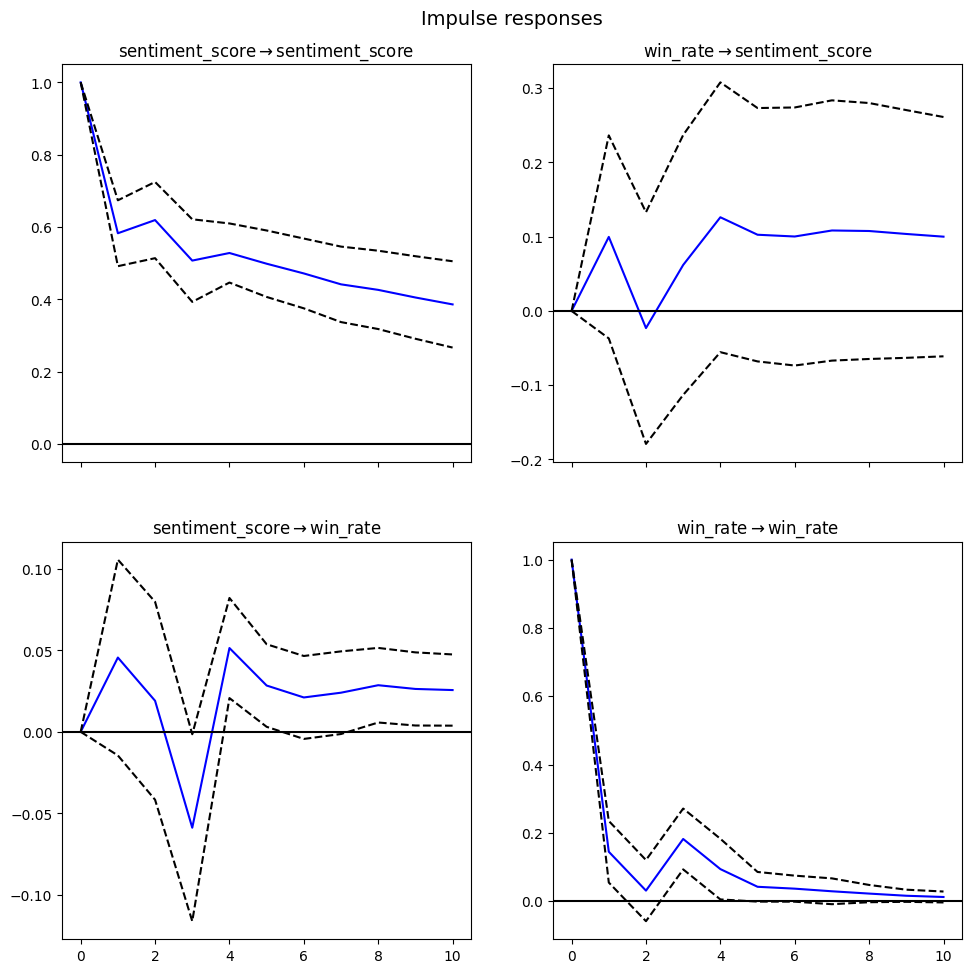

In [31]:
irf = results.irf(10)    # 10-day horizon
irf.plot(orth=False);


SyntaxError: invalid character '→' (U+2192) (2019850308.py, line 1)